## CNN-1D

In [ ]:
# CONFIGURACIÓN INICIAL
# =========================

import os, time, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
device = torch.device("cpu")
print(f"Using device: {device}")

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,accuracy_score,confusion_matrix,f1_score
)
from gensim.models import Word2Vec


Using device: cpu


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Darally06/NLP-Jarvis-Hiring/refs/heads/main/Data/Clean_words.csv')
df = df.rename(columns={'macro_label': 'Category'})
print(f"Registros totales: {len(df)}")

def ensure_list(x):
    """Convierte strings o listas a listas de tokens"""
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x.split()
    elif isinstance(x, list):
        return x
    else:
        return []

df['tokens'] = df['tokens'].apply(ensure_list)

# Codificación de etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])

# Dividir dataset en train/val/test
train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])
train, val, test = train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Registros totales: 2483
Train: 1738 | Val: 372 | Test: 373


In [3]:
# Funciones auxiliares
# -------------------------
def get_class_weights(train_df):
    """Crea pesos de clase balanceados según frecuencia"""
    weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
    return torch.tensor(weights, dtype=torch.float).to(device)

def tokens_to_ids(tokens, vocab):
    """Convierte lista de tokens a IDs según el vocabulario"""
    return [vocab.get(t, 0) for t in tokens]

# Dataset
class TextDataset(Dataset):
    """Dataset para CNN-1D que convierte tokens en IDs y aplica padding/truncamiento"""
    def __init__(self, texts, labels, vocab, seq_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.seq_len = seq_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.texts[idx]
        ids = tokens_to_ids(tokens, self.vocab)
        ids = ids[:self.seq_len] + [0] * max(0, self.seq_len - len(ids))
        return torch.tensor(ids), torch.tensor(self.labels[idx])

# -------------------------
# Modelo CNN-1D
# -------------------------
class CNN_Text(nn.Module):
    """CNN-1D para clasificación de texto con embeddings preentrenados"""
    def __init__(self, embedding_matrix, num_classes, filters=128, kernel_size=5, dropout=0.3):
        super(CNN_Text, self).__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=filters, kernel_size=kernel_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)       # (batch, embed_dim, seq_len)
        x = F.relu(self.conv1(x))                    # (batch, filters, L)
        x = F.max_pool1d(x, x.shape[2]).squeeze(2)  # (batch, filters)
        return self.fc(self.dropout(x))

> De ejecuciones anteriores, se realizo una hiperparmatetrización de 16 combinaciones, de las cuales se obtuvieron las 5 mejores:

|comb|filters |  kernel_size|  dropout_rate|  learning_rate|  batch_size  | val_acc  | test_ACC
|----|----|----|----|----|----|----|----|
|8       |256            |5           |0.3          |0.003        |   8 | 0.760753   | 0.638070
|1       |128            |5           |0.3          |0.003        |  16 | 0.755376   | 0.680965
|0       |128            |5           |0.3          |0.003        |   8 | 0.747312   | 0.664879
|9       |256            |5           |0.3          |0.003        |  16 | 0.747312   | 0.678284
|13      |256            |5           |0.5          |0.003        |  16 | 0.736559   |0.670241 

In [ ]:
# Embeddings Word2Vec
# -------------------------
embedding_dim = 200
w2v_path = r"C:\Users\danie\MODELS-NLP\results\BiLSTM\w2v_200.model"
w2v_model = Word2Vec.load(w2v_path)

vocab = w2v_model.wv.key_to_index
embedding_matrix = np.zeros((len(vocab), embedding_dim))
for word, idx in vocab.items():
    embedding_matrix[idx] = w2v_model.wv[word]
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

# Datasets y DataLoaders
# -------------------------
seq_len = 50
batch_size = 32

train_dataset = TextDataset(train['tokens'], train['label'], vocab, seq_len)
val_dataset   = TextDataset(val['tokens'], val['label'], vocab, seq_len)
test_dataset  = TextDataset(test['tokens'], test['label'], vocab, seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

# Inicialización del modelo y parámetros
# -------------------------
params = {
    "filters": 256,
    "kernel_size": 5,
    "dropout_rate": 0.3,
    "learning_rate": 0.003,
    "batch_size": 8,
    "sequence_length": 50,
    "num_epochs": 30
}

num_classes = len(le.classes_)
class_weights = get_class_weights(train)

model = CNN_Text(
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    filters=params["filters"],
    kernel_size=params["kernel_size"],
    dropout=params["dropout_rate"]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [29]:
# -------------------------
# Entrenamiento con validación y early stopping
# -------------------------
patience = 5                 # número de épocas sin mejora para detener
best_val_acc = 0
patience_counter = 0
history = {'train_loss': [], 'val_acc': []}

save_path = "results/CNN_1D"
os.makedirs(save_path, exist_ok=True)


time_start = time.time()
for epoch in range(params['num_epochs']):
    # ---- Entrenamiento ----
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    
    # ---- Validación ----
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_val.cpu().numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    
    # Guardar historia
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{params['num_epochs']} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # ---- Early stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Guardar el mejor modelo
        torch.save(model.state_dict(), os.path.join(save_path, "best_model.pt"))

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping activado en la época {epoch+1}")
            break

print("Tiempo de entrenamiento: %.2f minutos" % ((time.time() - time_start) / 60))
print(f"Mejor accuracy en validación: {best_val_acc:.4f}")

Epoch 1/30 | Train Loss: 1.4845 | Val Acc: 0.6452
Epoch 2/30 | Train Loss: 0.8391 | Val Acc: 0.7097
Epoch 3/30 | Train Loss: 0.5158 | Val Acc: 0.7177
Epoch 4/30 | Train Loss: 0.3544 | Val Acc: 0.7151
Epoch 5/30 | Train Loss: 0.3410 | Val Acc: 0.7204
Epoch 6/30 | Train Loss: 0.2226 | Val Acc: 0.7285
Epoch 7/30 | Train Loss: 0.1559 | Val Acc: 0.7258
Epoch 8/30 | Train Loss: 0.1118 | Val Acc: 0.7312
Epoch 9/30 | Train Loss: 0.1135 | Val Acc: 0.7258
Epoch 10/30 | Train Loss: 0.0944 | Val Acc: 0.7366
Epoch 11/30 | Train Loss: 0.0972 | Val Acc: 0.7285
Epoch 12/30 | Train Loss: 0.1180 | Val Acc: 0.7312
Epoch 13/30 | Train Loss: 0.1089 | Val Acc: 0.7446
Epoch 14/30 | Train Loss: 0.1396 | Val Acc: 0.7312
Epoch 15/30 | Train Loss: 0.1755 | Val Acc: 0.7016
Epoch 16/30 | Train Loss: 0.1968 | Val Acc: 0.7097
Epoch 17/30 | Train Loss: 0.2067 | Val Acc: 0.6909
Epoch 18/30 | Train Loss: 0.2506 | Val Acc: 0.7070
Early stopping activado en la época 18
Tiempo de entrenamiento: 2.08 minutos
Mejor accuracy


=== HIPERPARAMETROS DEL MODELO ===
filters: 256
kernel_size: 5
dropout_rate: 0.3
learning_rate: 0.003
batch_size: 8
sequence_length: 50
num_epochs: 30

=== MÉTRICAS EN TEST ===
Accuracy: 0.6890 | F1-macro: 0.6876

=== CLASSIFICATION REPORT ===
                                    precision    recall  f1-score   support

          Creatividad y Producción       0.82      0.59      0.69        63
               Negocios y Finanzas       0.79      0.76      0.77        88
            Otros y Especializados       0.52      0.62      0.56        71
Servicios Profesionales y Públicos       0.64      0.77      0.70        84
              Tecnología y Ciencia       0.79      0.66      0.72        67

                          accuracy                           0.69       373
                         macro avg       0.71      0.68      0.69       373
                      weighted avg       0.71      0.69      0.69       373


=== METRICAS POR CLASE ===


,precision,recall,f1-score
Creatividad y Producción,0.822222,0.587302,0.685185
Negocios y Finanzas,0.788235,0.761364,0.774566
Otros y Especializados,0.517647,0.619718,0.564103
Servicios Profesionales y Públicos,0.637255,0.773810,0.698925
Tecnología y Ciencia,0.785714,0.656716,0.715447


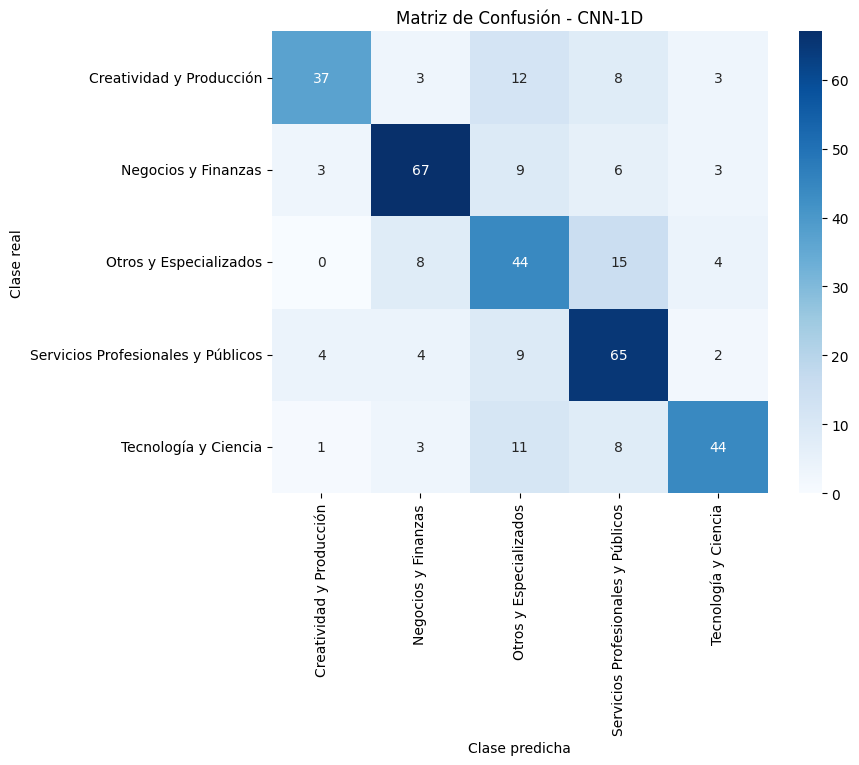


=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===


,Real,Pred
0,Otros y Especializados,Otros y Especializados
1,Servicios Profesionales y Públicos,Servicios Profesionales y Públicos
2,Creatividad y Producción,Creatividad y Producción
3,Creatividad y Producción,Creatividad y Producción
4,Negocios y Finanzas,Negocios y Finanzas
5,Tecnología y Ciencia,Tecnología y Ciencia
6,Otros y Especializados,Otros y Especializados
7,Creatividad y Producción,Otros y Especializados
8,Otros y Especializados,Servicios Profesionales y Públicos
9,Tecnología y Ciencia,Tecnología y Ciencia


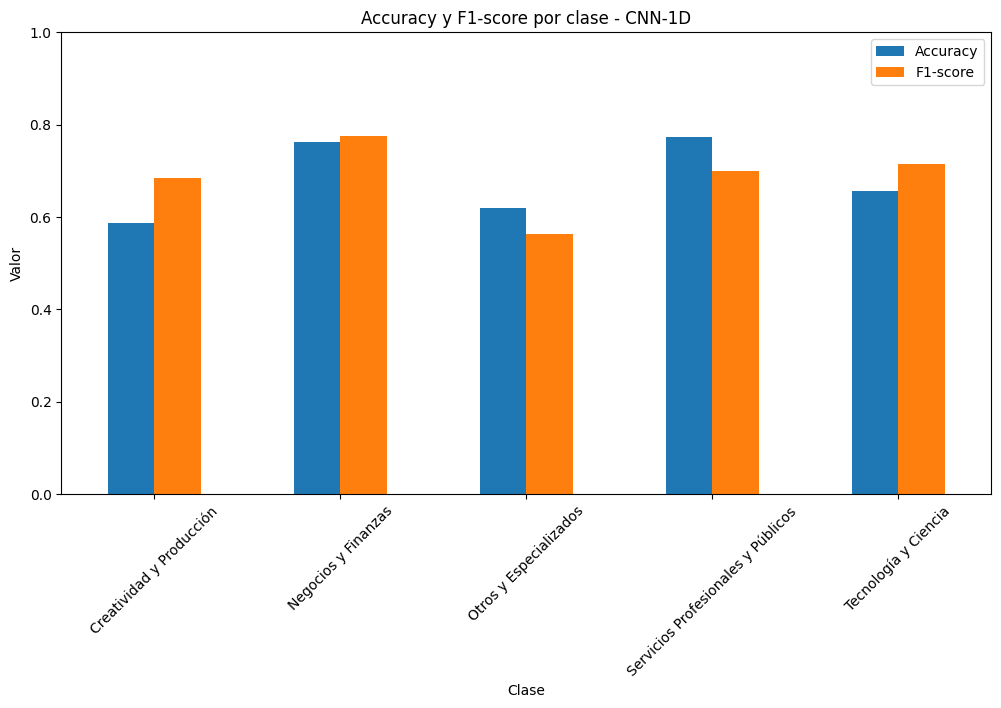

In [30]:
# Evaluación
# -------------------------
def evaluate_model(model, loader, device, label_encoder):
    """Evalúa el modelo y retorna métricas globales y reportes por clase"""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    report = classification_report(all_labels, all_preds, target_names=label_encoder.classes_, output_dict=True, zero_division=0)

    # Matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)

    return acc, f1, report, cm, all_labels, all_preds

# Evaluación sobre test
test_acc, test_f1, test_report, test_cm, test_labels, test_preds = evaluate_model(model, test_loader, device, le)


print("\n=== HIPERPARAMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

# ---- Métricas globales ----
print(f"\n=== MÉTRICAS EN TEST ===\nAccuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

# ---- Classification report ----
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(test_labels, test_preds, target_names=le.classes_, zero_division=0))

# ---- Resultados por clase ----
metrics_df = pd.DataFrame(test_report).transpose()
print("\n=== METRICAS POR CLASE ===")
display(metrics_df.iloc[:-3][['precision','recall','f1-score']])  # quitar avg/accuracy

# ---- Matriz de confusión ----
plt.figure(figsize=(8,6))
sns.heatmap(test_cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión - CNN-1D")
plt.show()

# ---- Comparar reales vs predichas por clase ----
comparison_df = pd.DataFrame({
    "Real": [le.classes_[i] for i in test_labels],
    "Pred": [le.classes_[i] for i in test_preds]
})
print("\n=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===")
display(comparison_df.head(10))

# ---- Gráfico de métricas por clase (Accuracy y F1) ----
per_class_f1 = [test_report[label]['f1-score'] for label in le.classes_]
per_class_acc = [np.mean((test_preds[test_labels==i] == i)) for i, _ in enumerate(le.classes_)]

metrics_plot_df = pd.DataFrame({
    "Clase": le.classes_,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})
metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind='bar', figsize=(12,6))
plt.title("Accuracy y F1-score por clase - CNN-1D")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()